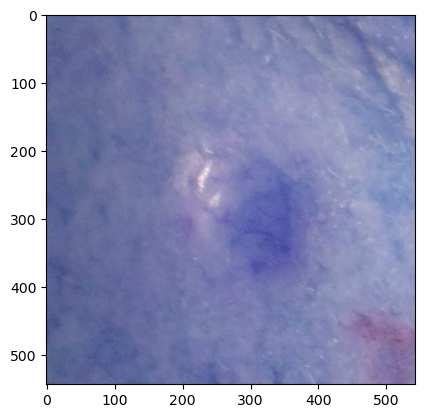

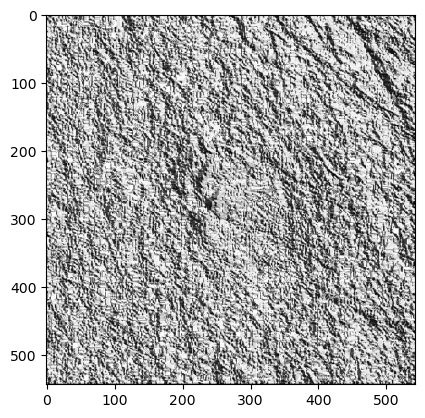

LBP Program is finished
[9.97657350e-03 5.51809121e-04 5.39621926e-03 4.06578377e-03
 6.36442422e-04 3.38533203e-05 3.68662658e-03 4.59389557e-03
 7.38340916e-03 4.70561153e-04 6.49983750e-04 7.41387715e-04
 4.89519012e-03 1.25257285e-04 1.98583577e-02 2.60535153e-02
 7.48158379e-04 4.06239844e-05 4.02854512e-04 4.13010508e-04
 4.06239844e-05 6.77066407e-06 6.77066407e-05 1.65881270e-04
 5.05091539e-03 5.11185137e-04 5.85662442e-04 1.15101289e-03
 6.01234969e-03 1.59110606e-04 2.38428935e-02 2.88464143e-02
 5.40298993e-03 3.69001192e-04 2.14968584e-03 7.95553028e-04
 3.92698516e-04 4.73946485e-05 7.10919727e-04 5.95818438e-04
 5.14570469e-04 2.03119922e-05 1.15101289e-04 2.36973242e-05
 5.55194453e-04 6.77066407e-06 1.22210486e-03 5.55194453e-04
 4.21473838e-03 4.36707832e-04 7.88782364e-04 3.24991875e-04
 9.47892969e-05 6.77066407e-06 2.84367891e-04 3.41918535e-04
 1.64933377e-02 1.56402340e-03 1.24580219e-03 1.36428881e-03
 1.83586556e-02 6.73681075e-04 3.26955368e-02 1.95333658e-02


In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
 
    
def get_pixel(img, center, x, y):
    
    new_value = 0
    
    try:
        # If local neighbourhood pixel 
        # value is greater than or equal
        # to center pixel values then 
        # set it to 1
        if img[x][y] >= center:
            new_value = 1
            
    except:
        # Exception is required when 
        # neighbourhood value of a center
        # pixel value is null i.e. values
        # present at boundaries.
        pass
    
    return new_value
 
# Function for calculating LBP
def lbp_calculated_pixel(img, x, y):
 
    center = img[x][y]
 
    val_ar = []
    
    # top_left
    val_ar.append(get_pixel(img, center, x-1, y-1))
    
    # top
    val_ar.append(get_pixel(img, center, x-1, y))
    
    # top_right
    val_ar.append(get_pixel(img, center, x-1, y + 1))
    
    # right
    val_ar.append(get_pixel(img, center, x, y + 1))
    
    # bottom_right
    val_ar.append(get_pixel(img, center, x + 1, y + 1))
    
    # bottom
    val_ar.append(get_pixel(img, center, x + 1, y))
    
    # bottom_left
    val_ar.append(get_pixel(img, center, x + 1, y-1))
    
    # left
    val_ar.append(get_pixel(img, center, x, y-1))
     
    # Now, we need to convert binary
    # values to decimal
    power_val = [1, 2, 4, 8, 16, 32, 64, 128]
 
    val = 0
    
    for i in range(len(val_ar)):
        val += val_ar[i] * power_val[i]
        
    return val
 
path = '../data/imgs/PAT_326_690_823.png'
img_bgr = cv2.imread(path)
 
height, width, _ = img_bgr.shape
 

img_gray = cv2.cvtColor(img_bgr,cv2.COLOR_BGR2GRAY)
img_lbp = np.zeros((height, width),np.uint8)
 
for i in range(0, height):
    for j in range(0, width):
        img_lbp[i, j] = lbp_calculated_pixel(img_gray, i, j)

plt.imshow(img_bgr)
plt.show()
 
plt.imshow(img_lbp, cmap ="gray")
plt.show()
 
print("LBP Program is finished")

height, width = img_gray.shape
    
img_lbp = np.zeros((height, width), np.uint8)
for i in range(0, height):
    for j in range(0, width):
        img_lbp[i, j] = lbp_calculated_pixel(img_gray, i, j)
    
hist, _ = np.histogram(img_lbp.ravel(), bins=256, range=(0, 256))

hist = hist.astype("float")
hist /= (hist.sum() + 1e-7)

print(hist)

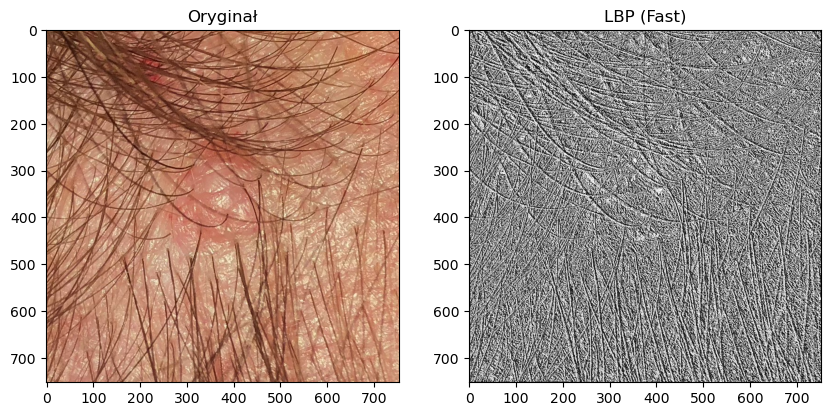

Szybkie LBP zakończone.
[0.04564301 0.00608456 0.01077937 0.00792756 0.00705456 0.00130157
 0.00862597 0.00989755 0.01095926 0.00133155 0.00218162 0.0018095
 0.00904218 0.00115695 0.01442658 0.01605442 0.00668596 0.00111991
 0.00148322 0.00113049 0.0013968  0.00030864 0.00134918 0.00129275
 0.00859246 0.00121162 0.002037   0.00146206 0.01241779 0.00139504
 0.02116016 0.01008626 0.01078819 0.00150791 0.00222042 0.00117988
 0.00178833 0.00026631 0.00126806 0.00101057 0.00241971 0.00025573
 0.00034215 0.00025044 0.0023527  0.00036155 0.00171779 0.00125395
 0.00835966 0.00114284 0.00125571 0.00101938 0.00138446 0.0003298
 0.00115166 0.00123455 0.01561175 0.00208815 0.00156435 0.00148322
 0.02249347 0.00268426 0.01416909 0.00841433 0.00706162 0.00132449
 0.00168957 0.00136682 0.00130157 0.0003104  0.00126277 0.00132449
 0.00175306 0.00029982 0.00029276 0.00030158 0.00125571 0.00029806
 0.00171602 0.00194177 0.00120104 0.00033509 0.00031746 0.00034038
 0.00033686 0.00014991 0.00026102 0.0004

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def fast_lbp(img):
    # Pobieramy wymiary obrazu
    rows, cols = img.shape
    # Przygotowujemy wynikową macierz (zerujemy ramki, bo ich nie liczymy)
    lbp = np.zeros((rows, cols), dtype=np.uint8)

    # Definiujemy przesunięcia dla 8 sąsiadów oraz ich wagi (potęgi 2)
    # Kolejność: top_left, top, top_right, right, bottom_right, bottom, bottom_left, left
    offsets = [(-1, -1), (-1, 0), (-1, 1), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1)]
    powers = [1, 2, 4, 8, 16, 32, 64, 128]

    for (dr, dc), power in zip(offsets, powers):
        # Tworzymy widoki przesuniętego obrazu (padding/slicing)
        # Przesuwamy obraz tak, aby sąsiad znalazł się na pozycji piksela centralnego
        shifted = np.roll(np.roll(img, -dr, axis=0), -dc, axis=1)
        
        # Maskowanie krawędzi (opcjonalne, ale zapobiega błędom zawijania roll)
        # Jeśli zależy Ci na czystości krawędzi, można wyciąć ramkę o szerokości 1
        
        # Logika LBP: jeśli sąsiad >= centrum, dodaj wagę
        lbp += ((shifted >= img) * power).astype(np.uint8)

    return lbp

# Wczytanie obrazu
path = '../data/imgs/PAT_21_31_965.png'
img_bgr = cv2.imread(path)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Szybkie obliczenia
img_lbp = fast_lbp(img_gray)

# Wyświetlanie wyników
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Oryginał")
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title("LBP (Fast)")
plt.imshow(img_lbp, cmap="gray")
plt.show()

# Histogram
hist, _ = np.histogram(img_lbp.ravel(), bins=256, range=(0, 256))
hist = hist.astype("float")
hist /= (hist.sum() + 1e-7)

print("Szybkie LBP zakończone.")
print(hist)

In [12]:

img_org = cv2.imread(path)
 

3//2

1

In [27]:
import pandas as pd

df = pd.read_csv('../data/features.csv')
df.head(10)

,img_id,FEATURE_A,FEATURE_B_R,FEATURE_B_G,FEATURE_B_B,FEATURE_BORDER_COMPACTNESS,FEATURE_BORDER_CONVEXITY,Cancerous,Hair,LBP_0,...,LBP_246,LBP_247,LBP_248,LBP_249,LBP_250,LBP_251,LBP_252,LBP_253,LBP_254,LBP_255
0,PAT_1516_1765_530.png,0.0013,143.099149,83.283015,40.318690,1.0,0.968849,0,0.0007,0.010405,...,0.000722,0.014681,0.036550,0.017812,0.000696,0.017191,0.016429,0.010028,0.016262,0.199856
1,PAT_46_881_939.png,0.0008,182.800784,136.578730,134.996534,1.0,0.897399,1,0.0021,0.052493,...,0.001466,0.020087,0.013749,0.011554,0.002244,0.009538,0.011112,0.017372,0.009724,0.160063
2,PAT_1545_1867_547.png,0.0009,181.347601,108.574183,103.481645,1.0,0.864815,0,0.0138,0.050090,...,0.000876,0.014475,0.018103,0.009521,0.003279,0.009048,0.009841,0.012393,0.010085,0.148752
3,PAT_1989_4061_934.png,0.0039,157.649514,130.654856,124.298790,1.0,0.937706,0,0.0000,0.038419,...,0.001863,0.017515,0.013092,0.012985,0.002194,0.013166,0.012616,0.017494,0.012608,0.142758
4,PAT_684_1302_588.png,0.0014,137.372770,88.520156,85.730339,1.0,0.955400,1,0.0070,0.023770,...,0.001389,0.016440,0.017567,0.014338,0.001616,0.011855,0.014875,0.015940,0.012249,0.117924
5,PAT_1549_1882_230.png,0.0014,137.443851,128.802862,118.348210,1.0,0.964240,0,0.1677,0.030578,...,0.001209,0.015514,0.018249,0.012385,0.001699,0.008655,0.011944,0.015353,0.008980,0.090767
6,PAT_778_1471_835.png,0.0039,216.206234,160.102853,129.577904,1.0,0.908278,1,0.1799,0.048869,...,0.001480,0.016140,0.011828,0.010848,0.001737,0.009220,0.011064,0.019565,0.009686,0.098669
7,PAT_1995_4080_695.png,0.0038,127.012392,76.788342,69.050669,1.0,0.262828,0,0.0479,0.042331,...,0.001045,0.015985,0.018521,0.011811,0.002083,0.008714,0.013088,0.016594,0.009531,0.116053
8,PAT_705_4015_413.png,0.0015,164.345658,140.986338,139.616895,1.0,0.789279,0,0.0009,0.058793,...,0.001248,0.018650,0.015058,0.010291,0.002603,0.008802,0.010762,0.017996,0.009087,0.179521
9,PAT_2140_4726_141.png,0.0012,218.475949,137.510719,128.485836,1.0,0.937305,0,0.1661,0.041298,...,0.001256,0.013256,0.017544,0.013214,0.002770,0.011404,0.012552,0.014755,0.013131,0.072575
